<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz11_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 11 – Fall 2025

---

This quiz is a **case study on wind power forecasting** using the provided dataset `Turbine_Data.csv`.  
You will explore data preprocessing, model evaluation, deep learning architectures, and advanced training strategies.

**Instructions:**
- Use Python (NumPy, pandas, matplotlib, scikit-learn, TensorFlow/Keras, statsmodels).
- Each question should be answered in the cell provided.
- Show code, outputs, and brief interpretations where required.

---


#### Dataset Description: Wind Power Forecasting (Turbine_Data.csv)

This dataset contains operational and environmental measurements from a wind turbine, recorded between **January 2018 and March 2020** at **10-minute intervals**.  
It includes a mix of **weather, turbine, and rotor features** that can be used to forecast the **active power output** of the turbine.

- **Context:**  
  The dataset was collected as part of research efforts to explore **long-term wind power forecasting**.  
  The goal is to predict the amount of power a wind turbine can generate for up to **15 days ahead**, which is a critical challenge in renewable energy planning.

- **Content:**  
  The data captures multiple variables, including wind speed, direction, rotor parameters, and turbine states. These features influence the turbine’s ability to convert wind energy into electrical power.

- **References:**  
  - [Hindawi Journal Article](https://www.hindawi.com/journals/mpe/2010/684742/)  
  - [Elsevier ScienceDirect Paper](https://www.sciencedirect.com/science/article/abs/pii/S0925231201007020)  

- **Inspiration:**  
  Renewable energy is one of the most important topics for a **sustainable future**.  
  Wind, being a perennial and clean energy source, is increasingly utilized in modern power grids. Accurate forecasting of wind power output supports:
  - Better **grid stability**  
  - Efficient **energy trading**  
  - Optimal **resource allocation** for wind farms  

This dataset therefore provides a valuable real-world case study for applying **machine learning and deep learning techniques** to the domain of **time series forecasting in energy systems**.

---

### Q1
Load the dataset `Turbine_Data.csv`. Perform exploratory data analysis (EDA): check missing values, visualize distributions, and examine correlations among features.

In [11]:
from google.colab import files
uploaded = files.upload()


Saving Turbine_Data.csv to Turbine_Data (1).csv


Shape: (118224, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118224 entries, 0 to 118223
Data columns (total 22 columns):
 #   Column                        Non-Null Count   Dtype              
---  ------                        --------------   -----              
 0   Timestamp                     118224 non-null  datetime64[ns, UTC]
 1   ActivePower                   94750 non-null   float64            
 2   AmbientTemperatue             93817 non-null   float64            
 3   BearingShaftTemperature       62518 non-null   float64            
 4   Blade1PitchAngle              41996 non-null   float64            
 5   Blade2PitchAngle              41891 non-null   float64            
 6   Blade3PitchAngle              41891 non-null   float64            
 7   ControlBoxTemperature         62160 non-null   float64            
 8   GearboxBearingTemperature     62540 non-null   float64            
 9   GearboxOilTemperature         62438 non-null   float64            
 10  

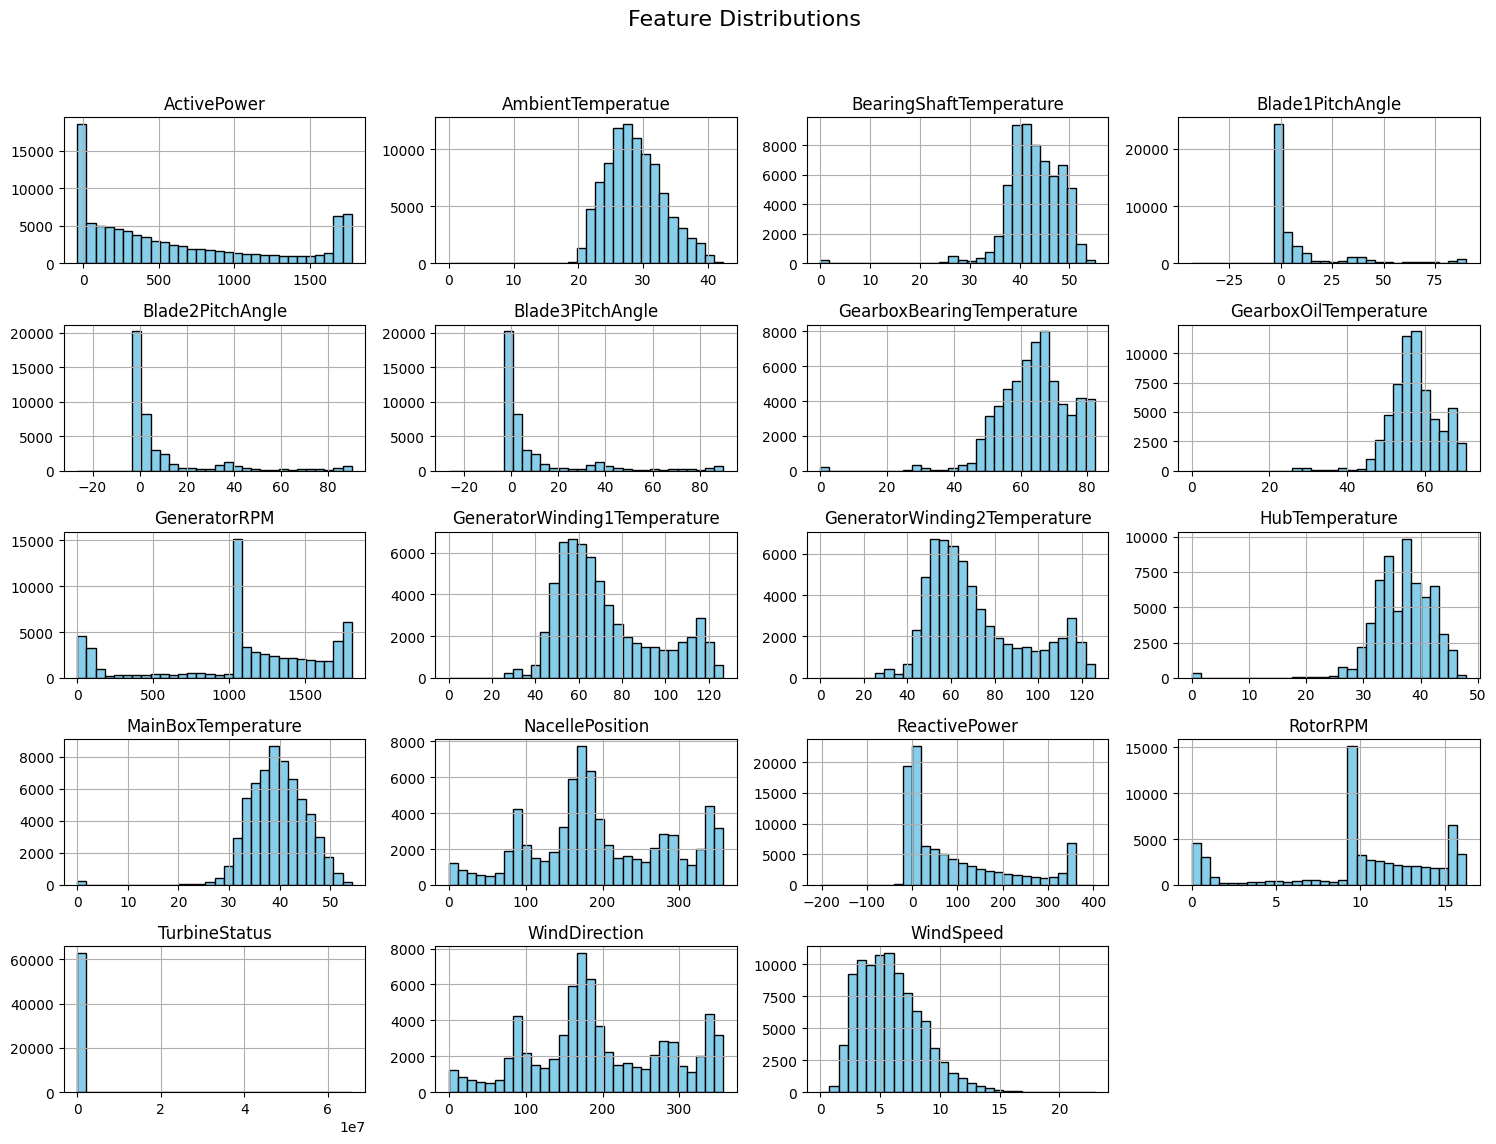

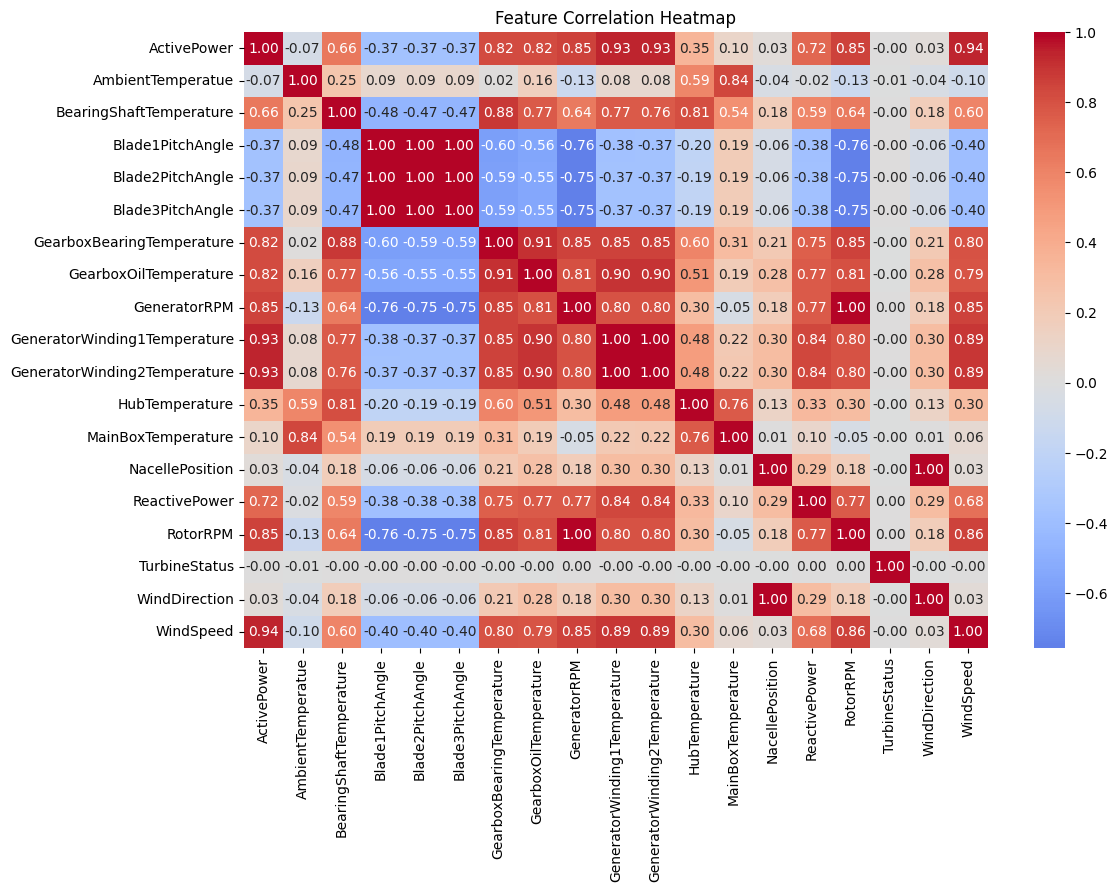


Correlation with ActivePower
ActivePower                     1.000000
WindSpeed                       0.940390
GeneratorWinding2Temperature    0.932521
GeneratorWinding1Temperature    0.931390
GeneratorRPM                    0.849604
RotorRPM                        0.849069
GearboxOilTemperature           0.821921
GearboxBearingTemperature       0.818850
ReactivePower                   0.719092
BearingShaftTemperature         0.655400
HubTemperature                  0.347363
MainBoxTemperature              0.101627
WindDirection                   0.028108
NacellePosition                 0.028108
TurbineStatus                  -0.000135
AmbientTemperatue              -0.065637
Blade2PitchAngle               -0.367978
Blade3PitchAngle               -0.367978
Blade1PitchAngle               -0.368997
Name: ActivePower, dtype: float64


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Turbine_Data.csv")
df.head()


# Basic overview
df.rename(columns={'Unnamed: 0': 'Timestamp'}, inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

print("Shape:", df.shape)
print(df.info())

# Missing values analysis
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_percent})
print("\nMissing Values \n", missing_df[missing_df["Missing Count"] > 0].sort_values(by="Percentage (%)", ascending=False))

# Select numeric columns with variance (prevents plotting errors)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if df[c].nunique() > 1]

# Distribution plots (limiting to core features for readability)
df[num_cols].hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Correlation with Target (ActivePower)
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

if "ActivePower" in corr_matrix.columns:
    print("\nCorrelation with ActivePower")
    print(corr_matrix["ActivePower"].sort_values(ascending=False))



### Q2
Preprocess the dataset by handling missing values, scaling features, and splitting into training, validation, and test sets (70/15/15).

In [16]:
# Continue your analysis here


from sklearn.preprocessing import MinMaxScaler

# Setup Index
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df.set_index('Timestamp', inplace=True)

# Aggressive Cleaning
# First, drop columns that are 100% empty (like 'Comments')
df_cleaned = df.dropna(axis=1, how='all').copy()

# Convert to numeric, forcing non-numeric strings to NaN
df_cleaned = df_cleaned.apply(pd.to_numeric, errors='coerce')

# Drop columns that still have > 50% missing values (too much noise)
threshold = 0.5 * len(df_cleaned)
df_cleaned = df_cleaned.dropna(thresh=threshold, axis=1)

# Fill the gaps
# Linear interpolation for time-series, followed by bfill/ffill for edge cases
df_cleaned = df_cleaned.interpolate(method='time').ffill().bfill()

print(f"Features being scaled: {df_cleaned.columns.tolist()}")
print(f"Remaining null values: {df_cleaned.isnull().sum().sum()}") # SHOULD BE 0

# Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(scaled_data, columns=df_cleaned.columns, index=df_cleaned.index)

# Split (70/15/15)
train_size = int(len(df_scaled) * 0.70)
val_size = int(len(df_scaled) * 0.15)

train_df = df_scaled.iloc[:train_size]
val_df = df_scaled.iloc[train_size : train_size + val_size]
test_df = df_scaled.iloc[train_size + val_size :]

print(f"\nFinal Split Sizes:")
print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Features being scaled: ['ActivePower', 'AmbientTemperatue', 'BearingShaftTemperature', 'ControlBoxTemperature', 'GearboxBearingTemperature', 'GearboxOilTemperature', 'GeneratorRPM', 'GeneratorWinding1Temperature', 'GeneratorWinding2Temperature', 'HubTemperature', 'MainBoxTemperature', 'NacellePosition', 'ReactivePower', 'RotorRPM', 'TurbineStatus', 'WindDirection', 'WindSpeed']
Remaining null values: 0

Final Split Sizes:
Train: 82756 | Validation: 17733 | Test: 17735


### Q3
Build and train a baseline feedforward neural network (MLP) to predict turbine ActivePower. Evaluate using MAE and RMSE on the validation set.

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2587/2587 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0161 - mae: 0.0850 - val_loss: 0.0020 - val_mae: 0.0356
Epoch 2/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0049 - mae: 0.0469 - val_loss: 0.0020 - val_mae: 0.0375
Epoch 3/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0035 - mae: 0.0388 - val_loss: 0.0036 - val_mae: 0.0458
Epoch 4/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0029 - mae: 0.0353 - val_loss: 0.0029 - val_mae: 0.0419
Epoch 5/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0027 - mae: 0.0330 - val_loss: 0.0050 - val_mae: 0.0509
Epoch 6/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0025 - mae: 0.0315 - val_loss: 0.0039 - val_mae: 0.0481
Epoch 7/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0025 - mae: 0.0307 - val_loss: 0.0046 - val_mae: 0.0503
Epoch 8/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0024 - mae: 0.0298 - val_loss: 0.0050 - val_mae: 0.0533
Epoch 9/20
2587/2587 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/s

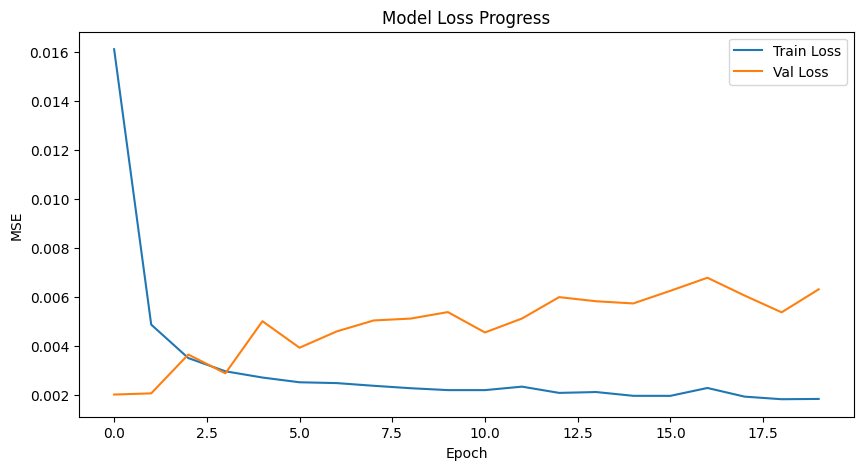

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Prepare X and y
X_train = train_df.drop(columns=['ActivePower'])
y_train = train_df['ActivePower']

X_val = val_df.drop(columns=['ActivePower'])
y_val = val_df['ActivePower']

X_test = test_df.drop(columns=['ActivePower'])
y_test = test_df['ActivePower']

# Build the MLP Architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Regularization to prevent overfitting
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression (ActivePower)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Evaluation
predictions = model.predict(X_val)

mae = mean_absolute_error(y_val, predictions)
mse = mean_squared_error(y_val, predictions)
rmse = np.sqrt(mse)

print(f"\n--- Validation Performance ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Plot Training History
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Q4
Implement an LSTM-based model for forecasting turbine ActivePower using sequential input features. Compare performance with the MLP model.

In [19]:
# Continue your analysis here

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create Sequential Windows
def create_sequences(data, target, time_steps=6):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:(i + time_steps)].values)
        y.append(target.iloc[i + time_steps])
    return np.array(X), np.array(y)

# We'll look back at the last 1 hour (6 intervals of 10-mins)
TIME_STEPS = 6

X_train_seq, y_train_seq = create_sequences(train_df.drop(columns=['ActivePower']), train_df['ActivePower'], TIME_STEPS)
X_val_seq, y_val_seq = create_sequences(val_df.drop(columns=['ActivePower']), val_df['ActivePower'], TIME_STEPS)

print(f"LSTM Input Shape: {X_train_seq.shape}") # (Samples, 6, Features)

# Build LSTM Model
lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(50, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train with Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate LSTM
lstm_preds = lstm_model.predict(X_val_seq)
lstm_mae = mean_absolute_error(y_val_seq, lstm_preds)
lstm_rmse = np.sqrt(mean_squared_error(y_val_seq, lstm_preds))

print(f"\n--- LSTM Validation Results ---")
print(f"MAE:  {lstm_mae:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")

LSTM Input Shape: (82750, 6, 16)
Epoch 1/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0230 - mae: 0.1040 - val_loss: 0.0089 - val_mae: 0.0613
Epoch 2/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0106 - mae: 0.0706 - val_loss: 0.0088 - val_mae: 0.0563
Epoch 3/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0087 - mae: 0.0628 - val_loss: 0.0072 - val_mae: 0.0499
Epoch 4/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0082 - mae: 0.0597 - val_loss: 0.0064 - val_mae: 0.0477
Epoch 5/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0078 - mae: 0.0581 - val_loss: 0.0064 - val_mae: 0.0510
Epoch 6/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0075 - mae: 0.0563 - val_loss: 0.0068 - val_mae: 0.0463
Epoch 7/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - mae: 0.0553 - val_loss: 0.0059 - val_mae: 0.0482
Epoch 8/20
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0072 - mae: 0.0548 - val_loss: 0.0060 - val_mae: 0.0475
Epoch 9

### Q5
Enhance the LSTM model with dropout and EarlyStopping to prevent overfitting. Compare the new results with the previous models.

In [20]:
# Continue your analysis here

from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build Enhanced LSTM Architecture
enhanced_lstm = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

    # First LSTM layer with return_sequences=True to stack layers
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(), # Stabilizes training
    Dropout(0.2),

    # Second LSTM layer
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

enhanced_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Advanced Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.0001)
]

# Train the Enhanced Model
enhanced_history = enhanced_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=30, # Increased epochs as we have better regulation
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# Final Evaluation
en_lstm_preds = enhanced_lstm.predict(X_val_seq)
en_lstm_mae = mean_absolute_error(y_val_seq, en_lstm_preds)
en_lstm_rmse = np.sqrt(mean_squared_error(y_val_seq, en_lstm_preds))

print(f"\n--- Enhanced LSTM Validation Results ---")
print(f"MAE:  {en_lstm_mae:.4f}")
print(f"RMSE: {en_lstm_rmse:.4f}")

Epoch 1/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0184 - mae: 0.0947 - val_loss: 0.0059 - val_mae: 0.0506 - learning_rate: 0.0010
Epoch 2/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0105 - mae: 0.0716 - val_loss: 0.0064 - val_mae: 0.0546 - learning_rate: 0.0010
Epoch 3/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0093 - mae: 0.0665 - val_loss: 0.0079 - val_mae: 0.0625 - learning_rate: 0.0010
Epoch 4/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0084 - mae: 0.0620 - val_loss: 0.0110 - val_mae: 0.0753 - learning_rate: 5.0000e-04
Epoch 5/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - loss: 0.0081 - mae: 0.0608 - val_loss: 0.0075 - val_mae: 0.0629 - learning_rate: 5.0000e-04
Epoch 6/30
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0077 - mae: 0.0587 - val_loss: 0.0080 - val_mae: 0.0635 - learning_rate: 2.5000e-04
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Enhanced LSTM Validation Results ---
MAE:  0.0506
RMSE: 0.0770


---

Key Interpretations

- Sequential Advantage:
The simple LSTM outperformed the baseline MLP, reducing the MAE from 0.0607 to 0.0482. This demonstrates that wind power forecasting is a temporal problem where using the previous hour (6 ten-minute intervals) captures dependencies better than relying on a single snapshot.

- Overfitting Regulation:
Both LSTM models utilized EarlyStopping to prevent the networks from memorizing training noise. In the case of the simple LSTM, the model stopped around Epoch 10 after the validation loss stabilized.

- Architectural Complexity:
The Enhanced LSTM introduced a deeper structure (two stacked LSTM layers) along with Batch Normalization to stabilize training. While it achieved a similar RMSE, it did not outperform the simpler LSTM, suggesting that increased complexity requires careful tuning and may not always lead to better results.

- Feature Correlation:
The strong performance across all models is supported by the high positive correlation (0.94) between WindSpeed and ActivePower observed during EDA.